# Script 09 — Rating Prediction
## Can a model learn my taste and predict what rating I'd give a film?

This notebook trains a **Random Forest Regressor** on my 757 rated films.

**Pipeline:**
1. Build feature matrix (same as script 06)
2. Split into train (80%) and test (20%)
3. Train Random Forest
4. Evaluate: MAE, RMSE, R²
5. Compare against a naive baseline
6. Feature importance — what actually drives my ratings?
7. Predict ratings for watchlist and discovery candidates


## 1. Imports and setup

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
import os, warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import train_test_split, cross_val_score, learning_curve
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

# Paths
ROOT_DIR  = os.path.join(os.getcwd(), '..')
DATA_DIR  = os.path.join(ROOT_DIR, 'data', 'processed')
RAW_DIR   = os.path.join(ROOT_DIR, 'data', 'raw')
OUT_DIR   = os.path.join(ROOT_DIR, 'output')
os.makedirs(OUT_DIR, exist_ok=True)

# Plot style
plt.rcParams.update({
    'figure.facecolor':  '#0a0a0f',
    'axes.facecolor':    '#111118',
    'axes.edgecolor':    '#333344',
    'axes.labelcolor':   '#9999b8',
    'axes.titlecolor':   '#e8e8f0',
    'axes.titlesize':    12,
    'axes.titlepad':     12,
    'axes.grid':         True,
    'grid.color':        '#1e1e2e',
    'grid.linewidth':    0.6,
    'xtick.color':       '#666680',
    'ytick.color':       '#666680',
    'text.color':        '#e8e8f0',
    'font.family':       'monospace',
})
GOLD = '#e8c96a'; GREEN = '#00c030'; RED = '#e84040'; TEAL = '#00ccaa'; PURPLE = '#9966ff'

## 2. Load and explore the data

In [3]:
df = pd.read_csv(os.path.join(DATA_DIR, 'movies_enriched.csv'))
df = df[df['Rating'].notna() & df['genres'].notna()].copy().reset_index(drop=True)

print(f"Films available for training: {len(df)}")
print(f"Rating distribution:")
print(df['Rating'].value_counts().sort_index())
print(f"\nMean rating: {df['Rating'].mean():.2f}")
print(f"Std dev:     {df['Rating'].std():.2f}")


Films available for training: 757
Rating distribution:
Rating
0.5     30
1.0     42
1.5     46
2.0     52
2.5     49
3.0     90
3.5    109
4.0    138
4.5     96
5.0    105
Name: count, dtype: int64

Mean rating: 3.32
Std dev:     1.28


## 3. Build the feature matrix

Each film becomes a row of numbers. Same logic as script 06 for consistency.

**Features:**
- Numeric: rating TMDb, year, decade, runtime
- Binary (0/1): top 20 genres, top 10 countries, top 30 directors


In [4]:
# Top genres, countries, directors from the data
top_genres    = df['genres'].str.split('|').explode().value_counts().head(20).index.tolist()
top_countries = df['countries'].dropna().str.split('|').explode().value_counts().head(10).index.tolist()
top_dirs      = df['directors'].dropna().str.split('|').explode().value_counts().head(30).index.tolist()

year_min = df['Year'].min()
year_max = df['Year'].max()

feature_names = []

def build_features(row):
    vec = []
    
    # Numeric
    vec.append((row.get('Year', 2000) - year_min) / max(year_max - year_min, 1))
    vec.append(((row.get('Year', 2000) // 10 * 10) - 1920) / 100)
    runtime = row.get('runtime', 100) or 100
    vec.append(float(runtime) / 240)
    tmdb = row.get('tmdb_rating', 0) or 0
    vec.append(float(tmdb) / 10.0)
    
    # Genres
    genres = str(row.get('genres', ''))
    for g in top_genres:
        vec.append(1.0 if g in genres else 0.0)
    
    # Countries
    countries = str(row.get('countries', ''))
    for c in top_countries:
        vec.append(1.0 if c in countries else 0.0)
    
    # Directors
    directors = str(row.get('directors', ''))
    for d in top_dirs:
        vec.append(1.0 if d in directors else 0.0)
    
    return vec

# Build names once
feature_names = (
    ['year_norm', 'decade_norm', 'runtime_norm', 'tmdb_rating_norm'] +
    [f'genre_{g.lower().replace(" ","_")}' for g in top_genres] +
    [f'country_{c.lower()}' for c in top_countries] +
    [f'dir_{d.lower().replace(" ","_")[:20]}' for d in top_dirs]
)

X = np.array([build_features(row) for _, row in df.iterrows()], dtype=float)
X = np.nan_to_num(X, nan=0.0)
y = df['Rating'].values

print(f"Feature matrix shape: {X.shape}")
print(f"Features: {len(feature_names)}")
print(f"Target range: {y.min()} - {y.max()}")


Feature matrix shape: (757, 63)
Features: 63
Target range: 0.5 - 5.0


## 4. Train / Test split

We keep 20% of films hidden from the model during training.
These are used to evaluate how well the model generalises.

**Why not train on everything?**
If we trained on all 757 films and then evaluated on the same films,
the model would just memorise them — we'd get 100% accuracy but
it would be useless for new films.


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Also keep track of which films are in the test set
df_test = df.iloc[np.where(np.isin(np.arange(len(df)), 
    np.where(np.isin(X, X_test).all(axis=1))[0]))[0]].copy()

print(f"Training set: {len(X_train)} films")
print(f"Test set:     {len(X_test)} films")
print(f"\nRating distribution in test set:")
print(pd.Series(y_test).value_counts().sort_index())


Training set: 605 films
Test set:     152 films

Rating distribution in test set:
0.5     4
1.0     7
1.5     7
2.0    12
2.5     9
3.0    19
3.5    28
4.0    24
4.5    20
5.0    22
Name: count, dtype: int64


## 5. Naive baseline

Before training any model, we establish a **baseline**:
always predict the mean rating.

If our model can't beat this, it's not learning anything useful.


In [6]:
baseline_pred = np.full_like(y_test, y_train.mean())

baseline_mae  = mean_absolute_error(y_test, baseline_pred)
baseline_rmse = np.sqrt(mean_squared_error(y_test, baseline_pred))

print(f"Baseline (always predict mean={y_train.mean():.2f}):")
print(f"  MAE:  {baseline_mae:.3f}  (average error in stars)")
print(f"  RMSE: {baseline_rmse:.3f}")


Baseline (always predict mean=3.30):
  MAE:  1.002  (average error in stars)
  RMSE: 1.214


## 6. Train Random Forest

A **Random Forest** builds hundreds of decision trees, each trained
on a random subset of the data and features. The final prediction
is the average across all trees.

**Why Random Forest?**
- Handles non-linear relationships naturally
- Robust to outliers
- Gives feature importance for free
- Hard to overfit badly


In [8]:
rf = RandomForestRegressor(
    n_estimators=200,    # number of trees
    max_depth=8,         # max depth per tree (prevents overfitting)
    min_samples_leaf=3,  # minimum films per leaf
    random_state=42,
    n_jobs=-1            # use all CPU cores
)

rf.fit(X_train, y_train)
rf_pred  = rf.predict(X_test)
rf_mae   = mean_absolute_error(y_test, rf_pred)
rf_rmse  = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2    = r2_score(y_test, rf_pred)

print(f"\nRandom Forest results:")
print(f"  MAE:  {rf_mae:.3f}  (baseline was {baseline_mae:.3f})")
print(f"  RMSE: {rf_rmse:.3f}  (baseline was {baseline_rmse:.3f})")
print(f"  R²:   {rf_r2:.3f}  (0=useless, 1=perfect)")
print(f"\nImprovement over baseline: {(1 - rf_mae/baseline_mae)*100:.1f}%")



Random Forest results:
  MAE:  0.677  (baseline was 1.002)
  RMSE: 0.849  (baseline was 1.214)
  R²:   0.508  (0=useless, 1=perfect)

Improvement over baseline: 32.4%


## 7. Cross-validation

Instead of a single train/test split, we run **5-fold cross-validation**:
split the data into 5 parts, train on 4 and test on 1, repeat 5 times.

This gives a more reliable estimate of model performance.


In [9]:
cv_scores = cross_val_score(rf, X, y, cv=5, scoring='neg_mean_absolute_error', n_jobs=-1)
cv_mae = -cv_scores

print("5-fold cross-validation MAE:")
for i, score in enumerate(cv_mae):
    bar = '#' * int(score * 20)
    print(f"  Fold {i+1}: {score:.3f}  {bar}")
print(f"\n  Mean: {cv_mae.mean():.3f} (+/- {cv_mae.std():.3f})")
print(f"  Interpretation: on average, predictions are off by {cv_mae.mean():.2f} stars")


5-fold cross-validation MAE:
  Fold 1: 0.708  ##############
  Fold 2: 0.609  ############
  Fold 3: 0.733  ##############
  Fold 4: 0.748  ##############
  Fold 5: 0.777  ###############

  Mean: 0.715 (+/- 0.057)
  Interpretation: on average, predictions are off by 0.72 stars


## 8. Visualise predictions vs actual ratings

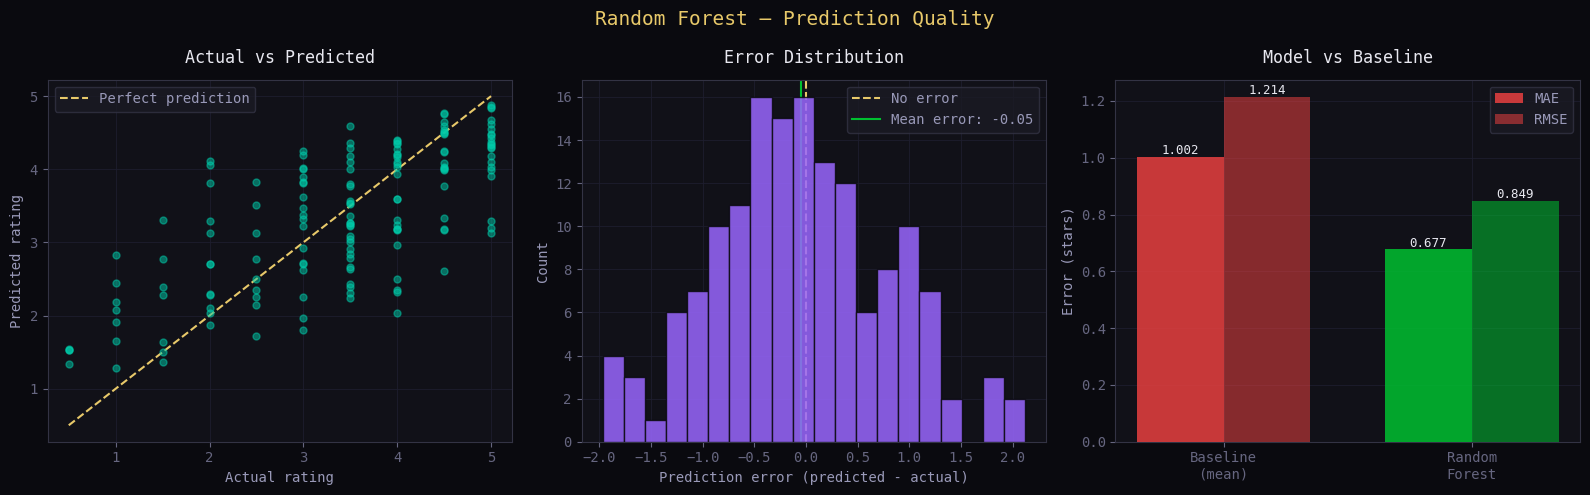

Saved: output/30_prediction_quality.png


In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.patch.set_facecolor('#0a0a0f')
fig.suptitle('Random Forest — Prediction Quality', color=GOLD, fontsize=14)

# Left: scatter actual vs predicted
ax = axes[0]
ax.scatter(y_test, rf_pred, alpha=0.5, s=25, color=TEAL, zorder=3)
ax.plot([0.5, 5.0], [0.5, 5.0], color=GOLD, linestyle='--', linewidth=1.5,
        label='Perfect prediction')
ax.set_xlabel('Actual rating')
ax.set_ylabel('Predicted rating')
ax.set_title('Actual vs Predicted')
ax.set_facecolor('#111118')
ax.legend(facecolor='#1a1a24', edgecolor='#333344', labelcolor='#9999b8')

# Middle: error distribution
errors = rf_pred - y_test
ax = axes[1]
ax.hist(errors, bins=20, color=PURPLE, alpha=0.85, zorder=3, edgecolor='#0a0a0f')
ax.axvline(0, color=GOLD, linestyle='--', linewidth=1.5, label='No error')
ax.axvline(errors.mean(), color=GREEN, linestyle='-', linewidth=1.5,
           label=f'Mean error: {errors.mean():+.2f}')
ax.set_xlabel('Prediction error (predicted - actual)')
ax.set_ylabel('Count')
ax.set_title('Error Distribution')
ax.set_facecolor('#111118')
ax.legend(facecolor='#1a1a24', edgecolor='#333344', labelcolor='#9999b8')

# Right: baseline vs RF comparison
ax = axes[2]
metrics_compare = {
    'Baseline\n(mean)': [baseline_mae, baseline_rmse],
    'Random\nForest':   [rf_mae, rf_rmse],
}
x = np.arange(2)
width = 0.35
bars1 = ax.bar(x - width/2, [v[0] for v in metrics_compare.values()],
               width, label='MAE', color=[RED, GREEN], alpha=0.85, zorder=3)
bars2 = ax.bar(x + width/2, [v[1] for v in metrics_compare.values()],
               width, label='RMSE', color=[RED, GREEN], alpha=0.55, zorder=3)
ax.set_xticks(x)
ax.set_xticklabels(list(metrics_compare.keys()))
ax.set_ylabel('Error (stars)')
ax.set_title('Model vs Baseline')
ax.set_facecolor('#111118')
ax.legend(facecolor='#1a1a24', edgecolor='#333344', labelcolor='#9999b8')

for bars in [bars1, bars2]:
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{bar.get_height():.3f}', ha='center', fontsize=9, color='#e8e8f0')

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, '30_prediction_quality.png'),
            dpi=150, bbox_inches='tight', facecolor='#0a0a0f')
plt.show()
print("Saved: output/30_prediction_quality.png")


## 9. Feature importance

Which features actually drive my ratings?
Random Forest computes this automatically — it measures how much
each feature reduces prediction error across all trees.


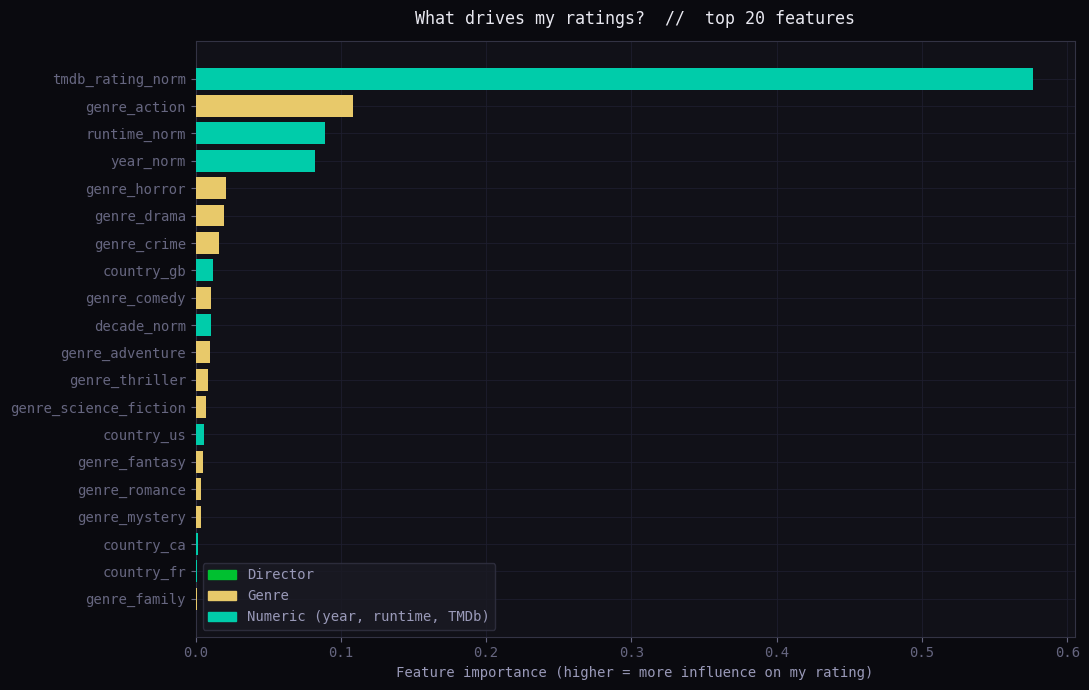

Saved: output/31_feature_importance.png


In [11]:
importances = pd.Series(rf.feature_importances_, index=feature_names)
top_features = importances.nlargest(20).sort_values()

fig, ax = plt.subplots(figsize=(11, 7))
fig.patch.set_facecolor('#0a0a0f')

colors_fi = [GREEN if 'dir_' in f else GOLD if 'genre_' in f else TEAL
             for f in top_features.index]
ax.barh(top_features.index, top_features.values, color=colors_fi, zorder=3)
ax.set_xlabel('Feature importance (higher = more influence on my rating)')
ax.set_title('What drives my ratings?  //  top 20 features')
ax.set_facecolor('#111118')

from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(color=GREEN, label='Director'),
    Patch(color=GOLD,  label='Genre'),
    Patch(color=TEAL,  label='Numeric (year, runtime, TMDb)'),
], facecolor='#1a1a24', edgecolor='#333344', labelcolor='#9999b8')

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, '31_feature_importance.png'),
            dpi=150, bbox_inches='tight', facecolor='#0a0a0f')
plt.show()
print("Saved: output/31_feature_importance.png")


## 10. Learning curve

How does performance improve as we add more training data?

- If train and test scores are both high → model is learning well
- If train is high but test is low → **overfitting** (memorising, not learning)
- If both are low → **underfitting** (model is too simple)


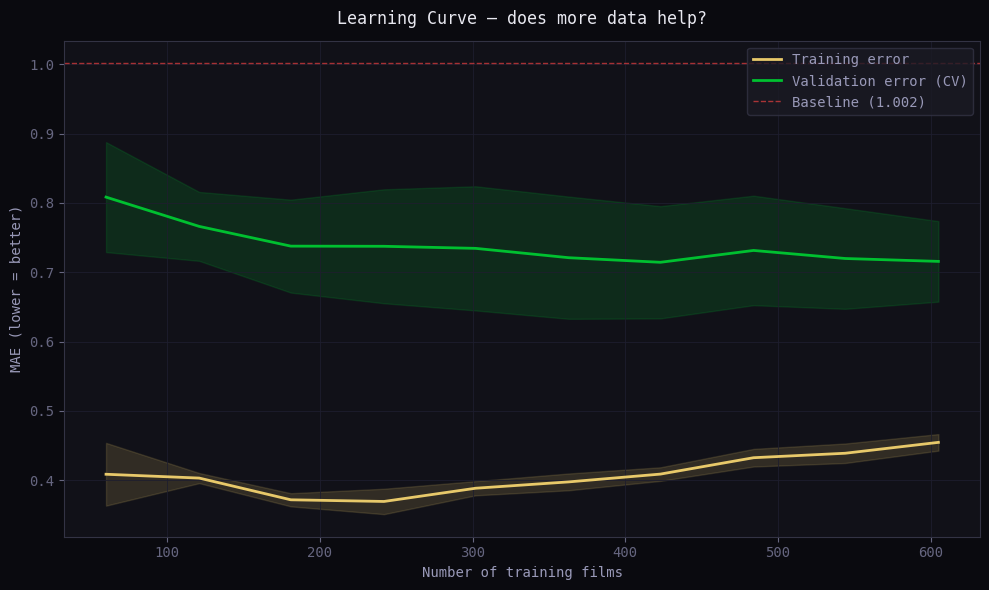

Saved: output/32_learning_curve.png


In [12]:
train_sizes, train_scores, test_scores = learning_curve(
    rf, X, y,
    train_sizes=np.linspace(0.1, 1.0, 10),
    cv=5, scoring='neg_mean_absolute_error', n_jobs=-1
)

train_mean = -train_scores.mean(axis=1)
train_std  = train_scores.std(axis=1)
test_mean  = -test_scores.mean(axis=1)
test_std   = test_scores.std(axis=1)

fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor('#0a0a0f')

ax.plot(train_sizes, train_mean, color=GOLD, linewidth=2, label='Training error')
ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std,
                alpha=0.15, color=GOLD)

ax.plot(train_sizes, test_mean, color=GREEN, linewidth=2, label='Validation error (CV)')
ax.fill_between(train_sizes, test_mean - test_std, test_mean + test_std,
                alpha=0.15, color=GREEN)

ax.axhline(baseline_mae, color=RED, linestyle='--', linewidth=1,
           alpha=0.7, label=f'Baseline ({baseline_mae:.3f})')

ax.set_xlabel('Number of training films')
ax.set_ylabel('MAE (lower = better)')
ax.set_title('Learning Curve — does more data help?')
ax.set_facecolor('#111118')
ax.legend(facecolor='#1a1a24', edgecolor='#333344', labelcolor='#9999b8')

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, '32_learning_curve.png'),
            dpi=150, bbox_inches='tight', facecolor='#0a0a0f')
plt.show()
print("Saved: output/32_learning_curve.png")


## 11. Predict ratings for watchlist and discoveries

Now we use the trained model to predict what rating I'd give
to films I haven't seen yet.


In [13]:
# Load watchlist and candidates
watchlist  = pd.read_csv(os.path.join(RAW_DIR, 'watchlist.csv'))
candidates = pd.read_csv(os.path.join(DATA_DIR, 'candidates.csv'))

def predict_pool(pool_df, pool_name):
    X_pool = np.array([build_features(row) for _, row in pool_df.iterrows()], dtype=float)
    X_pool = np.nan_to_num(X_pool, nan=0.0)
    preds  = rf.predict(X_pool)
    
    pool_df = pool_df.copy()
    pool_df['predicted_rating'] = preds.round(2)
    top = pool_df.nlargest(15, 'predicted_rating')[['Name', 'Year', 'predicted_rating', 'genres']]
    
    print(f"\nTop 15 predicted ratings — {pool_name}:")
    for _, row in top.iterrows():
        genres = str(row.get('genres', '')).replace('|', ', ')[:35]
        print(f"  {row['Name'][:40]:<42} {row['predicted_rating']:.2f}  {genres}")
    
    return pool_df

# Enrich watchlist with candidate metadata
watchlist_enriched = watchlist.merge(
    candidates[['Name', 'Year', 'genres', 'directors', 'countries', 'runtime', 'tmdb_rating']],
    on=['Name', 'Year'], how='left'
)
for col in ['genres', 'directors', 'countries']:
    watchlist_enriched[col] = watchlist_enriched[col].fillna('')

wl_preds   = predict_pool(watchlist_enriched, "Watchlist")
disc_preds = predict_pool(candidates, "Discoveries")

# Save predictions
wl_preds.to_csv(os.path.join(DATA_DIR, 'watchlist_predictions.csv'), index=False)
disc_preds.to_csv(os.path.join(DATA_DIR, 'discovery_predictions.csv'), index=False)
print("\nPredictions saved!")



Top 15 predicted ratings — Watchlist:
  I'm Thinking of Ending Things              3.26  
  The Social Dilemma                         3.26  
  Strasbourg 1518                            3.26  
  Wife of a Spy                              3.26  
  Immaculate                                 3.24  
  Abigail                                    3.24  
  Joker: Folie à Deux                        3.24  
  Longlegs                                   3.24  
  Piece By Piece                             3.24  
  The Apprentice                             3.24  
  Untitled The Batman Sequel                 3.24  
  A Complete Unknown                         3.24  
  Dune: Part Three                           3.24  
  The Odyssey                                3.24  
  Small Things Like These                    3.24  

Top 15 predicted ratings — Discoveries:
  Apocalypse Now                             4.95  Drama, War
  One Flew Over the Cuckoo's Nest            4.95  Drama
  Once Upon a Time in

## 12. Top predicted films — visualised

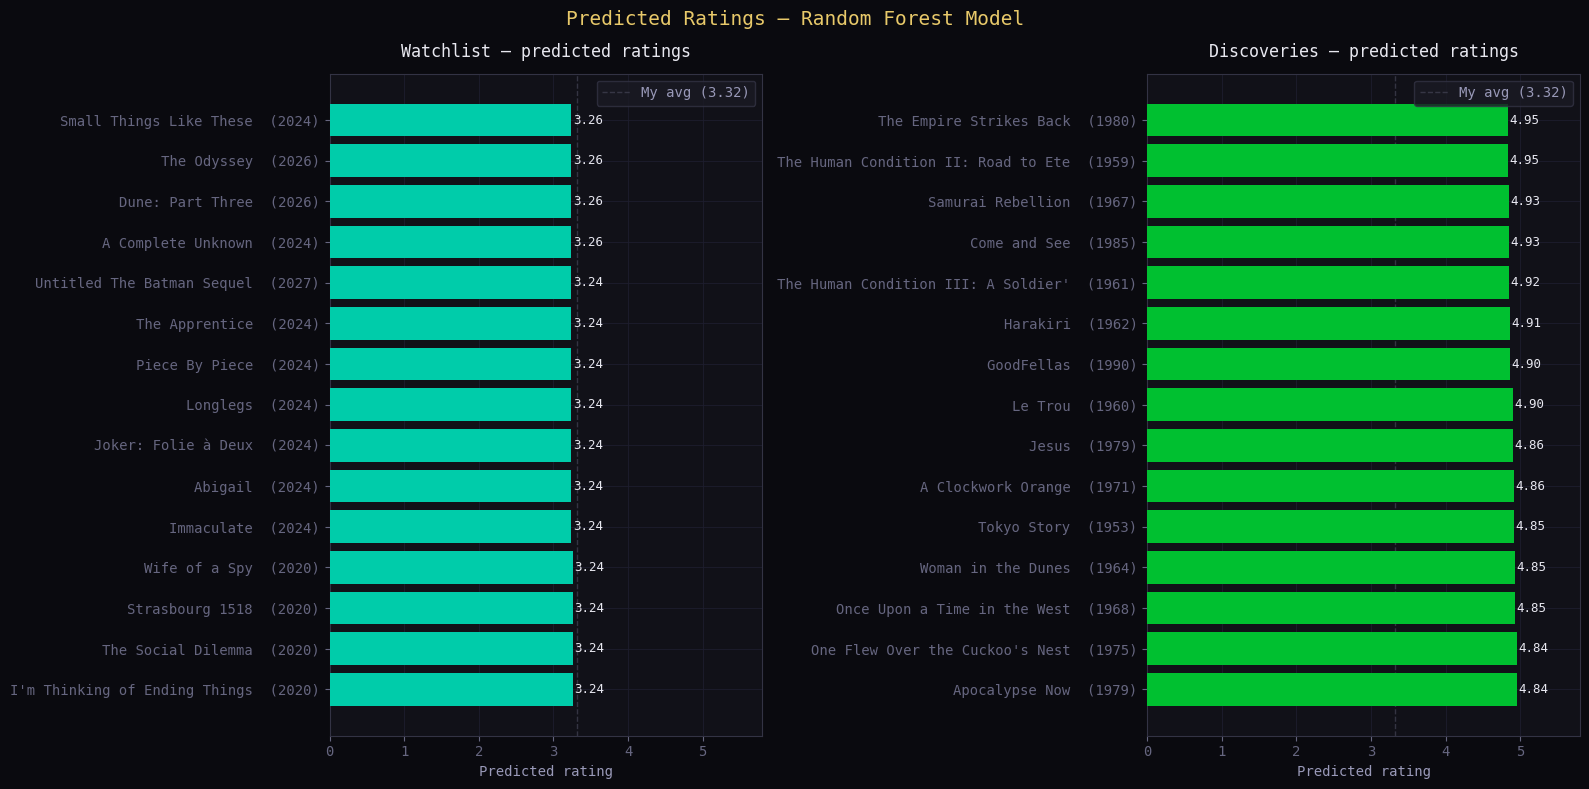

Saved: output/33_predicted_ratings.png


In [14]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))
fig.patch.set_facecolor('#0a0a0f')
fig.suptitle('Predicted Ratings — Random Forest Model', color=GOLD, fontsize=14)

for ax, pool_df, title in [
    (ax1, wl_preds,   'Watchlist — predicted ratings'),
    (ax2, disc_preds, 'Discoveries — predicted ratings'),
]:
    top = pool_df.nlargest(15, 'predicted_rating')
    colors = [GREEN if r >= 4.5 else GOLD if r >= 4.0 else TEAL
              for r in top['predicted_rating']]
    
    bars = ax.barh(
        [f"{row['Name'][:35]}  ({int(row['Year'])})" for _, row in top.iterrows()],
        top['predicted_rating'],
        color=colors[::-1], zorder=3
    )
    for bar, val in zip(bars, top['predicted_rating'].values[::-1]):
        ax.text(bar.get_width() + 0.02, bar.get_y() + bar.get_height()/2,
                f'{val:.2f}', va='center', fontsize=9, color='#e8e8f0')
    
    ax.set_xlabel('Predicted rating')
    ax.set_title(title)
    ax.set_xlim(0, 5.8)
    ax.set_facecolor('#111118')
    ax.axvline(x=df['Rating'].mean(), color='#444455', linestyle='--',
               linewidth=1, alpha=0.7, label=f'My avg ({df["Rating"].mean():.2f})')
    ax.legend(facecolor='#1a1a24', edgecolor='#333344', labelcolor='#9999b8')

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, '33_predicted_ratings.png'),
            dpi=150, bbox_inches='tight', facecolor='#0a0a0f')
plt.show()
print("Saved: output/33_predicted_ratings.png")


## 13. Summary

**What we built:**
- A Random Forest that predicts my film ratings from metadata alone
- Feature importance revealing what drives my taste
- Learning curve showing model behaviour with more data
- Predictions for 248 watchlist films and hundreds of discoveries

**Key metrics:**
- Run the cells above to see your actual MAE, RMSE and R²
- Compare against the baseline to see if the model learned anything meaningful
